<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_no_churn"] = df_collection["formated_table"].drop('churn', axis=1)
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["formated_table_with_keys_no_churn"] = get_table_with_keys(df_collection["formated_table_no_churn"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys_no_churn"], n)

#df_collection["formated_table_with_keys_no_churn"].head

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path

models = {}  

base_config = ModelConfig(
    vector_size = 50,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
    window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
    epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
    min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
    negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
    sample = 0,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
    hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
    alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
    seed = 1,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
)

GRID = {
    "vector_size": [150],
    "window": [4],
    "sg": [0, 1],
    "epochs": [30],
    "negative": [5],
    "sample": [1e-3],
    "hs": [0],
    "alpha": [0.025],
    "seed": [1]
}

trainer = ModelTrainer()
repository = ModelRepository(base_dir=Path.cwd())
runner = ExperimentRunner(trainer, repository, base_config)


models = runner.run_grid_search(
    sentences=df_collection["n_sentences"]["20"],
    param_grid=GRID,
    #n_sentences_tokenized=df_collection["n_sentences"],
    num_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
    verbose=False
)
    

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = []

        
for model in models:
    vectors = create_average_sentence_vectors(
        model, 
        df_collection["formated_table_with_keys"], 
        base_dir=Path.cwd(), 
        verbose=False
    )
    average_sentence_vectors.append([vectors, model[1]])
#print(average_sentence_vectors[1])

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.weighting_cosine_similarities import (
    run_experiment2_weighting_analysis
)

weight_vectors = {
    'average': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'weighted_base': [0, 1, 3, 3, 1, 1, 1, 3, 3, 3, 1],  # Wie Vorlesung
    'weighted_demographic': [0, 0, 5, 5, 0, 0, 0, 0, 0, 0, 0],
    'weighted_financial': [0, 5, 0, 0, 0, 0, 5, 0, 0, 0, 5]
}

results = run_experiment2_weighting_analysis(
    model_list=models,
    df_with_keys=df_collection["formated_table_with_keys"],
    weight_vectors=weight_vectors,
    run_churn_propensity=False,   # <- Szenario B aus
    verbose=True
)



Schritt 1: Redundante Spalten entfernen...
Entferne 4 Schlüsselspalten

Schritt 2: Kategorische Spalten identifizieren...
Gefundene kategorische Spalten: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Schritt 3: One-Hot Encoding durchführen...
Numerische Spalten: []

Ergebnis: 49 Features nach Encoding

EXPERIMENT 2: AVERAGING vs. WEIGHTING ANALYSE

Gewichtungsvektoren: ['average', 'weighted_base', 'weighted_demographic', 'weighted_financial']
Metriken: ['proximity_avg']

MODEL 0: {'Vector Size': 150, 'Window': 4, 'Algorithmus': 'CBOW', 'Kleinste Worthäufigkeit': 1, 'Workers': 4, 'Epochs': 30, 'Satzanzahl': 10000, 'Satzlänge': 300, 'Negative Sampling': 5, 'Sample': 0.001, 'Hierarchical Softmax': 0, 'Alpha': 0.025, 'Seed': 1}

[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] first 20 feature_names: ['key_1', 'Credit_Score_Fair', 'Country_France', 'Gender_Female', 'Age_Adults

In [5]:
ref = 2872
r = results["exp2_phase2_rankings_model0"][ref]["top"]["S_avg_average"]
print(type(r), r.columns, r.head())

o = results["exp2_phase2_overlaps_model0"][ref]["top_curves"]
print(type(o), o.shape, o.index[:5], o.columns)


<class 'pandas.core.frame.DataFrame'> Index(['Kunde_ID', 'score', 'rank'], dtype='object')       Kunde_ID     score  rank
4007      4008  0.904257     1
3031      3032  0.858063     2
6794      6795  0.856854     3
2399      2399  0.852629     4
1592      1592  0.852455     5
<class 'pandas.core.frame.DataFrame'> (200, 3) Index([1, 2, 3, 4, 5], dtype='int64', name='K') Index(['S_avg_weighted_base', 'S_avg_weighted_demographic',
       'S_avg_weighted_financial'],
      dtype='object')


In [6]:
df = []
stats = []

for model_num in [0, 1]:
    current_df = results[f"exp2_phase2_overlaps_agg_model{model_num}"]
    current_stats = results[f"exp2_phase3_summary_long_model{model_num}"]
    
    current_df["metric"] = current_df["metric"].str.replace("^S_avg_", "", regex=True)
    
    df.append(current_df)
    stats.append(current_stats)

import pandas as pd

def prepare_exp2_plot_data(results: dict, model_map=None):
    """
    Ergebnis-Frames für Visualisierung vorbereiten.
    model_map: {0:"CBOW", 1:"SGNS"} o.ä.
    """
    if model_map is None:
        model_map = {0: "CBOW", 1: "SGNS"}

    overlap_frames = []
    stats_frames = []

    for model_num, model_name in model_map.items():
        ov = results[f"exp2_phase2_overlaps_agg_model{model_num}"].copy()
        st = results[f"exp2_phase3_summary_long_model{model_num}"].copy()

        # Metriknamen vereinheitlichen: S_avg_weighted_base -> weighted_base
        if "metric" in ov.columns:
            ov["metric"] = ov["metric"].astype(str).str.replace("^S_avg_", "", regex=True)
        if "metric" in st.columns:
            st["metric"] = st["metric"].astype(str).str.replace("^S_avg_", "", regex=True)

        ov["model"] = model_name
        st["model"] = model_name

        overlap_frames.append(ov)
        stats_frames.append(st)

    overlap_agg_all = pd.concat(overlap_frames, ignore_index=True)
    stats_all = pd.concat(stats_frames, ignore_index=True)

    # Für konsistente Plot-Reihenfolge:
    metric_order = ["weighted_base", "weighted_demographic", "weighted_financial"]
    overlap_agg_all["metric"] = pd.Categorical(overlap_agg_all["metric"], categories=metric_order, ordered=True)
    stats_all["metric"] = pd.Categorical(stats_all["metric"], categories=(["average"] + metric_order), ordered=True)

    return overlap_agg_all, stats_all


In [7]:
overlap_agg_all, stats_all = prepare_exp2_plot_data(results)


<h2>Visualisierung<h2>

In [12]:
"""
Visualisierungsstrategie für Weight Vector Control Study - Scenario A
======================================================================

Bereinigte Version:
- Korrekte Kodierung: Farbe = Weight Vector, Hatching = Model (CBOW/SGNS)
- Legenden überdecken keine Daten (nach außen oder Figure-Legende)
- Stabile Reihenfolge über Categorical.categories (keine unique()-Zufälligkeiten)
- Robustere Annotationen (bar_label), weniger Layout-Artefakte (tight_layout rect)
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple, Optional
from collections import OrderedDict

# ============================================================================
# GLOBAL STYLING
# ============================================================================

def setup_plotting_style():
    """
    Konsistenter Stil für alle Plots (Publication-Ready)
    """
    plt.style.use('seaborn-v0_8-paper')
    sns.set_context("paper", font_scale=1.2)
    sns.set_palette("colorblind")

    plt.rcParams.update({
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'legend.frameon': True,
        'legend.edgecolor': 'black',
        'legend.fancybox': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'axes.spines.top': False,
        'axes.spines.right': False
    })


# Farbschema für Weight Vectors (konsistent über alle Plots)
WEIGHT_COLORS = {
    'average': '#2E86AB',               # Blau (Baseline)
    'weighted_base': '#A23B72',         # Magenta (Lecture)
    'weighted_demographic': '#F18F01',  # Orange
    'weighted_financial': '#C73E1D'     # Rot
}

WEIGHT_LABELS = {
    'average': r'$w^{(\mathrm{avg})}$ (Baseline)',
    'weighted_base': r'$w^{(\mathrm{weighted})}$ (Lecture)',
    'weighted_demographic': r'$w^{(\mathrm{demo})}$',
    'weighted_financial': r'$w^{(\mathrm{fin})}$'
}

# Modellkodierung über Hatch (damit Farbe Weight Vector bleiben kann)
MODEL_HATCHES = {
    "CBOW": "",
    "SGNS": "///"
}


def _ordered_metrics_from_categorical(series: pd.Series) -> List[str]:
    """Stabile Metrik-Reihenfolge: bevorzugt Categorical.categories."""
    if hasattr(series, "cat"):
        return [m for m in series.cat.categories if pd.notna(m)]
    return list(pd.unique(series))


def _dedup_legend(ax, loc="upper left", bbox_to_anchor=None, fontsize=9, title=None):
    """Legende deduplizieren, Reihenfolge erhalten, leere Labels entfernen."""
    handles, labels = ax.get_legend_handles_labels()
    od = OrderedDict()
    for h, l in zip(handles, labels):
        if l and (l not in od):
            od[l] = h
    if bbox_to_anchor is None:
        ax.legend(od.values(), od.keys(), loc=loc, fontsize=fontsize, title=title, framealpha=0.95)
    else:
        ax.legend(od.values(), od.keys(), loc=loc, bbox_to_anchor=bbox_to_anchor,
                  fontsize=fontsize, title=title, framealpha=0.95)


def _barplot_weightcolor_modelhatch(
    ax,
    plot_df: pd.DataFrame,
    ycol: str,
    metrics_order: List[str],
    model_order: List[str],
    width: float = 0.35,
    ylabel: str = "",
    xlabel: str = "Weight Vector",
    title: str = "",
):
    """
    Bars: Farbe = Weight Vector, Hatch = Model.
    Legende: Model (Proxy-Patches), damit keine falsche Farblegende entsteht.
    """
    x_pos = np.arange(len(metrics_order))

    for i, model in enumerate(model_order):
        md = (plot_df[plot_df["model"] == model]
              .set_index("metric")
              .reindex(metrics_order)
              .reset_index())

        offset = width * (i - 0.5)

        bars = ax.bar(
            x_pos + offset,
            md[ycol].values,
            width=width,
            color=[WEIGHT_COLORS.get(m, "#999999") for m in md["metric"]],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.9,
            zorder=3
        )
        for b in bars:
            b.set_hatch(MODEL_HATCHES.get(model, ""))

    ax.set_xticks(x_pos)
    ax.set_xticklabels([WEIGHT_LABELS.get(m, m) for m in metrics_order], rotation=15, ha="right")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold", loc="left")
    ax.grid(axis="y", alpha=0.3)

    # Modell-Legende via Proxy (semantisch korrekt)
    model_handles = [
        mpatches.Patch(facecolor="white", edgecolor="black",
                       hatch=MODEL_HATCHES.get(m, ""), label=m)
        for m in model_order
    ]
    ax.legend(handles=model_handles, title="Model", loc="upper left", fontsize=9, framealpha=0.95)


# ============================================================================
# EVALUATION DIMENSION 1: DISCRIMINATORY SPAN
# ============================================================================

def plot_discriminatory_span_composite(
    stats_all: pd.DataFrame,
    model_map: Dict[int, str] = None,
    figsize: Tuple[float, float] = (14, 8),
    save_path: Optional[str] = None
) -> plt.Figure:
    """
    Composite Figure für Discriminatory Span Analysis:
    - Panel A: Range (max - min) per weight vector
    - Panel B: Standard Deviation per weight vector
    - Panel C: Proportion of Negative Similarities
    - Panel D: Distribution Span (Mean ± Range)
    """
    if model_map is None:
        model_map = {0: "CBOW", 1: "SGNS"}

    stats_all = stats_all.copy()
    stats_all["range"] = stats_all["max"] - stats_all["min"]

    model_order = list(model_map.values())
    metrics_order = _ordered_metrics_from_categorical(stats_all["metric"])

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(
        "Discriminatory Span Analysis: Weight Vector Comparison",
        fontsize=13, fontweight="bold", y=0.98
    )

    # -------------------- PANEL A: Range --------------------
    ax = axes[0, 0]
    plot_data_a = (stats_all.groupby(["model", "metric"], observed=True)["range"]
                   .mean().reset_index())
    _barplot_weightcolor_modelhatch(
        ax=ax,
        plot_df=plot_data_a,
        ycol="range",
        metrics_order=metrics_order,
        model_order=model_order,
        ylabel="Range (max - min)",
        title="(A) Similarity Range"
    )

    # -------------------- PANEL B: Std ----------------------
    ax = axes[0, 1]
    plot_data_b = (stats_all.groupby(["model", "metric"], observed=True)["std"]
                   .mean().reset_index())
    _barplot_weightcolor_modelhatch(
        ax=ax,
        plot_df=plot_data_b,
        ycol="std",
        metrics_order=metrics_order,
        model_order=model_order,
        ylabel="Standard Deviation",
        title="(B) Similarity Dispersion"
    )

    # -------------------- PANEL C: Negative Similarities -----
    ax = axes[1, 0]
    if "neg_frac" in stats_all.columns:
        plot_data_c = (stats_all.groupby(["model", "metric"], observed=True)["neg_frac"]
                       .mean().reset_index())
        plot_data_c["neg_frac_pct"] = plot_data_c["neg_frac"] * 100

        _barplot_weightcolor_modelhatch(
            ax=ax,
            plot_df=plot_data_c,
            ycol="neg_frac_pct",
            metrics_order=metrics_order,
            model_order=model_order,
            ylabel="Negative Similarities (%)",
            title="(C) Proportion of Negative Similarities"
        )
        ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    else:
        ax.text(0.5, 0.5, "neg_frac data not available",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title("(C) Proportion of Negative Similarities", fontweight="bold", loc="left")

    # -------------------- PANEL D: Mean ± Range --------------
    ax = axes[1, 1]

    # stabile Reihenfolge für Modelle
    models = model_order
    metrics = metrics_order

    # x-Positionen: pro Metric zwei Punkte (CBOW/SGNS), plus Gap
    pos = 0.0
    point_positions = []
    point_meta = []  # (metric, model, x)
    for metric in metrics:
        for model in models:
            point_positions.append(pos)
            point_meta.append((metric, model, pos))
            pos += 1.0
        pos += 0.5  # Gap zwischen Metrics

    for metric, model, x in point_meta:
        subset = stats_all[(stats_all["metric"] == metric) & (stats_all["model"] == model)]
        if len(subset) == 0:
            continue

        mean_val = subset["mean"].mean()
        min_val = subset["min"].mean()
        max_val = subset["max"].mean()

        ax.errorbar(
            x, mean_val,
            yerr=[[mean_val - min_val], [max_val - mean_val]],
            fmt="o",
            markersize=7,
            capsize=4,
            capthick=1.5,
            color=WEIGHT_COLORS.get(metric, "#999999"),
            alpha=0.9,
            zorder=3
        )

    ax.set_xlabel("Weight Vector")  # KORRIGIERT
    ax.set_ylabel("Similarity Value")
    ax.set_title("(D) Distribution Span (Mean ± Range)", fontweight="bold", loc="left")
    ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.grid(axis="y", alpha=0.3)

    # X-Ticks: jeweils Mitte pro Metric-Gruppe
    tick_positions = []
    tick_labels = []
    pos = 0.0
    for metric in metrics:
        mid = pos + (len(models) - 1) / 2.0
        tick_positions.append(mid)
        tick_labels.append(WEIGHT_LABELS.get(metric, metric))
        pos += len(models) + 0.5
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=15, ha="right")

    # Legende für Panel D: Weight Vector Farben als Proxy, weil hier nur Punkte
    handles = [
        mpatches.Patch(facecolor=WEIGHT_COLORS.get(m, "#999999"),
                       edgecolor="black", label=WEIGHT_LABELS.get(m, m))
        for m in metrics
    ]
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              fontsize=8, framealpha=0.95)

    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    return fig


# ============================================================================
# EVALUATION DIMENSION 2: RANKING OVERLAP
# ============================================================================

def plot_overlap_curves(
    overlap_agg_all: pd.DataFrame,
    side: str = "top",
    model_map: Dict[int, str] = None,
    K_max: int = 200,
    figsize: Tuple[float, float] = (12, 5),
    save_path: Optional[str] = None,
    use_shared_legend: bool = True
) -> plt.Figure:
    """
    Overlap Curves gegen Baseline (w^(avg)) für Top-K und Bottom-K Rankings.
    Legenden werden außerhalb platziert (keine Überdeckung).
    """
    if model_map is None:
        model_map = {0: "CBOW", 1: "SGNS"}

    plot_data = overlap_agg_all[
        (overlap_agg_all["side"] == side) &
        (overlap_agg_all["K"] <= K_max)
    ].copy()

    models = _ordered_metrics_from_categorical(plot_data["model"])  # falls categorical
    if len(models) == 0:
        models = list(pd.unique(plot_data["model"]))

    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=figsize, sharey=True)
    if n_models == 1:
        axes = [axes]

    fig.suptitle(
        f"Ranking Overlap Curves: {side.capitalize()}-{K_max} vs. Baseline",
        fontsize=13, fontweight="bold", y=0.98
    )

    # Metriken stabil: bevorzugt categorical order aus prepare_exp2_plot_data
    metric_order = _ordered_metrics_from_categorical(plot_data["metric"])

    for ax, model in zip(axes, models):
        model_data = plot_data[plot_data["model"] == model]

        K_vals = np.arange(1, K_max + 1)
        ax.plot(K_vals, K_vals, "k--", linewidth=1.5, alpha=0.4,
                label="Perfect overlap", zorder=1)

        for metric in metric_order:
            metric_data = model_data[model_data["metric"] == metric].sort_values("K")
            if len(metric_data) == 0:
                continue

            ax.plot(
                metric_data["K"], metric_data["overlap_mean"],
                color=WEIGHT_COLORS.get(metric, "#999999"),
                linewidth=2,
                alpha=0.9,
                label=WEIGHT_LABELS.get(metric, metric),
                marker="o", markersize=3, markevery=20,
                zorder=3
            )

            if "overlap_std" in metric_data.columns:
                ax.fill_between(
                    metric_data["K"],
                    metric_data["overlap_mean"] - metric_data["overlap_std"],
                    metric_data["overlap_mean"] + metric_data["overlap_std"],
                    color=WEIGHT_COLORS.get(metric, "#999999"),
                    alpha=0.12,
                    zorder=2
                )

        ax.set_xlabel("K (Top-K Rank Threshold)" if side == "top" else "K (Bottom-K Rank Threshold)")
        if ax == axes[0]:
            ax.set_ylabel("Overlapping Customer IDs\n(vs. $w^{(\\mathrm{avg})}$)")
        ax.set_title(f"{model}", fontweight="bold")
        ax.set_xlim(0, K_max)
        ax.set_ylim(0, K_max)
        ax.grid(True, alpha=0.3)

        ax.text(
            0.05, 0.95, "High deviation\nfrom baseline",
            transform=ax.transAxes, fontsize=8,
            va="top", alpha=0.7,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3, edgecolor="none")
        )

        if not use_shared_legend:
            ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0.0),
                      borderaxespad=0, fontsize=8, framealpha=0.95)

    if use_shared_legend:
        # gemeinsame Legende (stabiler, weniger Überdeckung)
        handles, labels = axes[0].get_legend_handles_labels()
        for a in axes:
            if a.get_legend() is not None:
                a.get_legend().remove()

        fig.legend(handles, labels, loc="lower center", ncol=4,
                   frameon=True, fontsize=8)
        fig.tight_layout(rect=[0, 0.08, 1, 0.96])
    else:
        fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    return fig


def plot_overlap_heatmap(
    overlap_agg_all: pd.DataFrame,
    K_values: List[int] = [50, 100, 150, 200],
    side: str = "top",
    figsize: Tuple[float, float] = (10, 6),
    save_path: Optional[str] = None
) -> plt.Figure:
    """
    Heatmap der Overlap-Werte für diskrete K-Werte.
    """
    plot_data = overlap_agg_all[
        (overlap_agg_all["side"] == side) &
        (overlap_agg_all["K"].isin(K_values))
    ].copy()

    models = list(pd.unique(plot_data["model"]))
    n_models = len(models)

    fig, axes = plt.subplots(1, n_models, figsize=figsize)
    if n_models == 1:
        axes = [axes]

    fig.suptitle(f"Overlap Heatmap: {side.capitalize()}-K Rankings",
                 fontsize=13, fontweight="bold", y=0.98)

    for ax, model in zip(axes, models):
        model_data = plot_data[plot_data["model"] == model]
        pivot = model_data.pivot_table(
            index="metric",
            columns="K",
            values="overlap_mean",
            aggfunc="mean",
            observed=True
        )

        metric_order = ["weighted_base", "weighted_demographic", "weighted_financial"]
        pivot = pivot.reindex([m for m in metric_order if m in pivot.index])

        pivot.index = [WEIGHT_LABELS.get(m, m) for m in pivot.index]

        sns.heatmap(
            pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            cbar_kws={"label": "Overlapping IDs"},
            linewidths=0.5, linecolor="gray",
            vmin=0, vmax=max(K_values),
            ax=ax
        )

        ax.set_xlabel("K (Rank Threshold)")
        ax.set_ylabel("Weight Vector")
        ax.set_title(f"{model}", fontweight="bold")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    return fig


# ============================================================================
# EVALUATION DIMENSION 3: OPERATOR SENSITIVITY (Model Comparison)
# ============================================================================

def plot_model_sensitivity_comparison(
    overlap_agg_all: pd.DataFrame,
    stats_all: pd.DataFrame,
    figsize: Tuple[float, float] = (14, 5),
    save_path: Optional[str] = None
) -> plt.Figure:
    """
    Direkte Vergleiche zwischen Modellen (CBOW vs SGNS):
    - Panel A: Overlap difference (Δ overlap at K=100)
    - Panel B: Range difference (Δ discriminatory span)
    - Panel C: Correlation between models
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle("Model Sensitivity: CBOW vs. SGNS Comparison",
                 fontsize=13, fontweight="bold", y=0.98)

    models = list(pd.unique(overlap_agg_all["model"]))
    if len(models) != 2:
        raise ValueError("Dieser Plot benötigt genau 2 Modelle für Vergleich")

    model1, model2 = sorted(models)

    # -------------------- PANEL A: Δ Overlap @ K=100 --------------------
    ax = axes[0]
    ov_k100 = overlap_agg_all[
        (overlap_agg_all["K"] == 100) &
        (overlap_agg_all["side"] == "top")
    ].copy()

    ov1 = ov_k100[ov_k100["model"] == model1].set_index("metric")["overlap_mean"]
    ov2 = ov_k100[ov_k100["model"] == model2].set_index("metric")["overlap_mean"]

    metrics_to_compare = ["weighted_base", "weighted_demographic", "weighted_financial"]
    delta_overlap = (ov2 - ov1).reindex(metrics_to_compare)

    # falls etwas fehlt: NaN nicht annotieren
    x = np.arange(len(metrics_to_compare))
    bars = ax.bar(
        x,
        [delta_overlap.get(m, np.nan) for m in metrics_to_compare],
        color=[WEIGHT_COLORS.get(m, "#999999") for m in metrics_to_compare],
        alpha=0.85, edgecolor="black", linewidth=1
    )

    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
    ax.set_xlabel("Weight Vector")
    ax.set_ylabel(f"Δ Overlap\n({model2} - {model1})")
    ax.set_title("(A) Overlap Difference at K=100", fontweight="bold", loc="left")
    ax.set_xticks(x)
    ax.set_xticklabels([WEIGHT_LABELS.get(m, m) for m in metrics_to_compare], rotation=15, ha="right")
    ax.grid(axis="y", alpha=0.3)

    # robuste Labels
    label_text = []
    for m in metrics_to_compare:
        v = delta_overlap.get(m, np.nan)
        label_text.append(f"{v:.0f}" if np.isfinite(v) else "")
    ax.bar_label(bars, labels=label_text, padding=3, fontsize=9)

    # -------------------- PANEL B: Δ Range ------------------------------
    ax = axes[1]
    st = stats_all.copy()
    st["range"] = st["max"] - st["min"]

    range_agg = (st.groupby(["model", "metric"], observed=True)["range"]
                 .mean().reset_index())

    r1 = range_agg[range_agg["model"] == model1].set_index("metric")["range"]
    r2 = range_agg[range_agg["model"] == model2].set_index("metric")["range"]

    delta_range = (r2 - r1).reindex(metrics_to_compare)

    x = np.arange(len(metrics_to_compare))
    bars = ax.bar(
        x,
        [delta_range.get(m, np.nan) for m in metrics_to_compare],
        color=[WEIGHT_COLORS.get(m, "#999999") for m in metrics_to_compare],
        alpha=0.85, edgecolor="black", linewidth=1
    )

    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
    ax.set_xlabel("Weight Vector")
    ax.set_ylabel(f"Δ Range\n({model2} - {model1})")
    ax.set_title("(B) Discriminatory Span Difference", fontweight="bold", loc="left")
    ax.set_xticks(x)
    ax.set_xticklabels([WEIGHT_LABELS.get(m, m) for m in metrics_to_compare], rotation=15, ha="right")
    ax.grid(axis="y", alpha=0.3)

    label_text = []
    for m in metrics_to_compare:
        v = delta_range.get(m, np.nan)
        label_text.append(f"{v:.3f}" if np.isfinite(v) else "")
    ax.bar_label(bars, labels=label_text, padding=3, fontsize=9)

    # -------------------- PANEL C: Correlation Scatter -------------------
    ax = axes[2]

    ov_top = overlap_agg_all[overlap_agg_all["side"] == "top"].copy()
    ov_m1 = ov_top[ov_top["model"] == model1][["metric", "K", "overlap_mean"]].rename(columns={"overlap_mean": "overlap_m1"})
    ov_m2 = ov_top[ov_top["model"] == model2][["metric", "K", "overlap_mean"]].rename(columns={"overlap_mean": "overlap_m2"})
    merged = pd.merge(ov_m1, ov_m2, on=["metric", "K"])

    metric_order = _ordered_metrics_from_categorical(merged["metric"])

    for metric in metric_order:
        md = merged[merged["metric"] == metric]
        if len(md) == 0:
            continue
        ax.scatter(
            md["overlap_m1"], md["overlap_m2"],
            color=WEIGHT_COLORS.get(metric, "#999999"),
            label=WEIGHT_LABELS.get(metric, metric),
            alpha=0.65, s=30, edgecolors="black", linewidth=0.4
        )

    max_val = float(max(merged["overlap_m1"].max(), merged["overlap_m2"].max()))
    ax.plot([0, max_val], [0, max_val], "k--", linewidth=1, alpha=0.5, label="Perfect correlation")

    ax.set_xlabel(f"Overlap ({model1})")
    ax.set_ylabel(f"Overlap ({model2})")
    ax.set_title("(C) Model Correlation", fontweight="bold", loc="left")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

    # Legende nach außen (keine Punkte überdecken)
    _dedup_legend(ax, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)

    fig.tight_layout(rect=[0, 0, 0.88, 0.95])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    return fig


# ============================================================================
# HELPER FUNCTION
# ============================================================================

def prepare_exp2_plot_data(results: dict, model_map: Dict[int, str] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Bereitet Experiment 2 Daten für Visualisierung vor.
    """
    if model_map is None:
        model_map = {0: "CBOW", 1: "SGNS"}

    overlap_frames = []
    stats_frames = []

    for model_num, model_name in model_map.items():
        ov = results[f"exp2_phase2_overlaps_agg_model{model_num}"].copy()
        st = results[f"exp2_phase3_summary_long_model{model_num}"].copy()

        if "metric" in ov.columns:
            ov["metric"] = ov["metric"].astype(str).str.replace("^S_avg_", "", regex=True)
        if "metric" in st.columns:
            st["metric"] = st["metric"].astype(str).str.replace("^S_avg_", "", regex=True)

        ov["model"] = model_name
        st["model"] = model_name

        overlap_frames.append(ov)
        stats_frames.append(st)

    overlap_agg_all = pd.concat(overlap_frames, ignore_index=True)
    stats_all = pd.concat(stats_frames, ignore_index=True)

    metric_order = ["weighted_base", "weighted_demographic", "weighted_financial"]
    overlap_agg_all["metric"] = pd.Categorical(
        overlap_agg_all["metric"],
        categories=metric_order,
        ordered=True
    )
    stats_all["metric"] = pd.Categorical(
        stats_all["metric"],
        categories=(["average"] + metric_order),
        ordered=True
    )

    return overlap_agg_all, stats_all



# ============================================================================
# COMPREHENSIVE REPORT: ALL PLOTS IN ONE GO
# ============================================================================

def generate_complete_scenario_a_report(
    results: dict,
    model_map: Dict[int, str] = None,
    output_dir: str = "./figures",
    dpi: int = 300
) -> None:
    """
    Generiert alle Visualisierungen für Scenario A in einem Durchgang.
    
    Parameters:
    -----------
    results : dict
        Ausgabe von run_experiment2_weighting_analysis()
    model_map : dict
        {0: "CBOW", 1: "SGNS"}
    output_dir : str
        Verzeichnis zum Speichern der Plots
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    setup_plotting_style()
    
    print("="*70)
    print("GENERATING SCENARIO A VISUALIZATION REPORT")
    print("="*70)
    
    # Prepare data
    print("\n[1/7] Preparing data...")
    #from visualization_strategy import prepare_exp2_plot_data
    overlap_agg_all, stats_all = prepare_exp2_plot_data(results, model_map=model_map)
    
    print(f"  - Overlap data shape: {overlap_agg_all.shape}")
    print(f"  - Stats data shape: {stats_all.shape}")
    
    # Plot 1: Discriminatory Span Composite
    print("\n[2/7] Generating Discriminatory Span Analysis...")
    fig1 = plot_discriminatory_span_composite(
        stats_all=stats_all,
        model_map=model_map,
        save_path=f"{output_dir}/01_discriminatory_span_composite.png"
    )
    plt.close(fig1)
    
    # Plot 2: Overlap Curves (Top-200)
    print("\n[3/7] Generating Overlap Curves (Top-200)...")
    fig2 = plot_overlap_curves(
        overlap_agg_all=overlap_agg_all,
        side='top',
        model_map=model_map,
        K_max=200,
        save_path=f"{output_dir}/02_overlap_curves_top200.png"
    )
    plt.close(fig2)
    
    # Plot 3: Overlap Curves (Bottom-200)
    print("\n[4/7] Generating Overlap Curves (Bottom-200)...")
    fig3 = plot_overlap_curves(
        overlap_agg_all=overlap_agg_all,
        side='bottom',
        model_map=model_map,
        K_max=200,
        save_path=f"{output_dir}/03_overlap_curves_bottom200.png"
    )
    plt.close(fig3)
    
    # Plot 4: Overlap Heatmap (Top)
    print("\n[5/7] Generating Overlap Heatmap (Top)...")
    fig4 = plot_overlap_heatmap(
        overlap_agg_all=overlap_agg_all,
        K_values=[50, 100, 150, 200],
        side='top',
        save_path=f"{output_dir}/04_overlap_heatmap_top.png"
    )
    plt.close(fig4)
    
    # Plot 5: Overlap Heatmap (Bottom)
    print("\n[6/7] Generating Overlap Heatmap (Bottom)...")
    fig5 = plot_overlap_heatmap(
        overlap_agg_all=overlap_agg_all,
        K_values=[50, 100, 150, 200],
        side='bottom',
        save_path=f"{output_dir}/05_overlap_heatmap_bottom.png"
    )
    plt.close(fig5)
    
    # Plot 6: Model Sensitivity Comparison
    print("\n[7/7] Generating Model Sensitivity Comparison...")
    try:
        fig6 = plot_model_sensitivity_comparison(
            overlap_agg_all=overlap_agg_all,
            stats_all=stats_all,
            save_path=f"{output_dir}/06_model_sensitivity_comparison.png"
        )
        plt.close(fig6)
    except ValueError as e:
        print(f"  Warning: Could not generate model comparison plot: {e}")
    
    print("\n" + "="*70)
    print(f"REPORT COMPLETE: All figures saved to {output_dir}/")
    print("="*70)
    print("\nGenerated Figures:")
    print("  1. 01_discriminatory_span_composite.png")
    print("     → 4-panel analysis of range, std, negative sims, distribution")
    print("  2. 02_overlap_curves_top200.png")
    print("     → Ranking overlap for most similar customers (K=1..200)")
    print("  3. 03_overlap_curves_bottom200.png")
    print("     → Ranking overlap for most distinct customers (K=1..200)")
    print("  4. 04_overlap_heatmap_top.png")
    print("     → Discrete K-values heatmap (top rankings)")
    print("  5. 05_overlap_heatmap_bottom.png")
    print("     → Discrete K-values heatmap (bottom rankings)")
    print("  6. 06_model_sensitivity_comparison.png")
    print("     → Direct CBOW vs SGNS comparison")
    print("\n")


# ============================================================================
# HELPER FUNCTION (replicated from your code)
# ============================================================================

def prepare_exp2_plot_data(results: dict, model_map: Dict[int, str] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Bereitet Experiment 2 Daten für Visualisierung vor.
    
    Returns:
    --------
    overlap_agg_all : pd.DataFrame
        Aggregierte Overlap curves mit Spalten: model, side, K, metric, overlap_mean, ...
    stats_all : pd.DataFrame
        Summary statistics mit Spalten: model, metric, min, max, mean, std, neg_frac, ...
    """
    if model_map is None:
        model_map = {0: "CBOW", 1: "SGNS"}
    
    overlap_frames = []
    stats_frames = []
    
    for model_num, model_name in model_map.items():
        # Overlap aggregates
        ov = results[f"exp2_phase2_overlaps_agg_model{model_num}"].copy()
        st = results[f"exp2_phase3_summary_long_model{model_num}"].copy()
        
        # Clean metric names: S_avg_weighted_base -> weighted_base
        if "metric" in ov.columns:
            ov["metric"] = ov["metric"].astype(str).str.replace("^S_avg_", "", regex=True)
        if "metric" in st.columns:
            st["metric"] = st["metric"].astype(str).str.replace("^S_avg_", "", regex=True)
        
        ov["model"] = model_name
        st["model"] = model_name
        
        overlap_frames.append(ov)
        stats_frames.append(st)
    
    overlap_agg_all = pd.concat(overlap_frames, ignore_index=True)
    stats_all = pd.concat(stats_frames, ignore_index=True)
    
    # Für konsistente Plot-Reihenfolge
    metric_order = ["weighted_base", "weighted_demographic", "weighted_financial"]
    overlap_agg_all["metric"] = pd.Categorical(
        overlap_agg_all["metric"], 
        categories=metric_order, 
        ordered=True
    )
    stats_all["metric"] = pd.Categorical(
        stats_all["metric"], 
        categories=(["average"] + metric_order), 
        ordered=True
    )
    
    return overlap_agg_all, stats_all


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    """
    Beispiel-Workflow für Visualisierung
    """
    
    # Angenommen, du hast bereits:
    # results = run_experiment2_weighting_analysis(...)
    
    # Option 1: Alle Plots auf einmal generieren
    # generate_complete_scenario_a_report(
    #     results=results,
    #     model_map={0: "CBOW", 1: "SGNS"},
    #     output_dir="./figures_scenario_a",
    #     dpi=300
    # )
    
    # Option 2: Einzelne Plots gezielt erstellen
    # setup_plotting_style()
    # overlap_agg_all, stats_all = prepare_exp2_plot_data(results)
    # 
    # fig = plot_overlap_curves(
    #     overlap_agg_all=overlap_agg_all,
    #     side='top',
    #     model_map={0: "CBOW", 1: "SGNS"},
    #     K_max=200,
    #     save_path="overlap_curves_custom.png"
    # )
    # plt.show()
    
    print("Visualisierungsstrategie geladen!")
    print("\nVerfügbare Funktionen:")
    print("  - plot_discriminatory_span_composite()")
    print("  - plot_overlap_curves()")
    print("  - plot_overlap_heatmap()")
    print("  - plot_model_sensitivity_comparison()")
    print("  - generate_complete_scenario_a_report()")


Visualisierungsstrategie geladen!

Verfügbare Funktionen:
  - plot_discriminatory_span_composite()
  - plot_overlap_curves()
  - plot_overlap_heatmap()
  - plot_model_sensitivity_comparison()
  - generate_complete_scenario_a_report()


In [13]:
generate_complete_scenario_a_report(
    results=results,
    model_map={0: "CBOW", 1: "SGNS"},
    output_dir="./figures_scenario_a"
)

GENERATING SCENARIO A VISUALIZATION REPORT

[1/7] Preparing data...
  - Overlap data shape: (2400, 8)
  - Stats data shape: (40, 9)

[2/7] Generating Discriminatory Span Analysis...
Figure saved to: ./figures_scenario_a/01_discriminatory_span_composite.png

[3/7] Generating Overlap Curves (Top-200)...
Figure saved to: ./figures_scenario_a/02_overlap_curves_top200.png

[4/7] Generating Overlap Curves (Bottom-200)...
Figure saved to: ./figures_scenario_a/03_overlap_curves_bottom200.png

[5/7] Generating Overlap Heatmap (Top)...
Figure saved to: ./figures_scenario_a/04_overlap_heatmap_top.png

[6/7] Generating Overlap Heatmap (Bottom)...
Figure saved to: ./figures_scenario_a/05_overlap_heatmap_bottom.png

[7/7] Generating Model Sensitivity Comparison...
Figure saved to: ./figures_scenario_a/06_model_sensitivity_comparison.png

REPORT COMPLETE: All figures saved to ./figures_scenario_a/

Generated Figures:
  1. 01_discriminatory_span_composite.png
     → 4-panel analysis of range, std, neg

In [8]:
"""
Visualisierungsstrategie für Weight Vector Control Study - Scenario A
======================================================================

Basierend auf der Experimentbeschreibung werden folgende drei Dimensionen evaluiert:
1. Discriminatory Span (range, dispersion, negative similarities)
2. Ranking Overlap (overlap curves gegen baseline)
3. Operator Sensitivity (Vergleich über Modelle)

Datenverfügbarkeit:
- exp2_phase2_overlaps_agg_model{N}: Overlap curves (aggregiert über Referenzkunden)
- exp2_phase3_summary_long_model{N}: Summary statistics (min, max, mean, std, neg_frac)
- exp2_phase3_hist_long_model{N}: Histogramme (optional, für detaillierte Verteilungen)
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple, Optional

# ============================================================================
# GLOBAL STYLING
# ============================================================================

def setup_plotting_style():
    """
    Konsistenter Stil für alle Plots (Publication-Ready)
    """
    plt.style.use('seaborn-v0_8-paper')
    sns.set_context("paper", font_scale=1.2)
    sns.set_palette("colorblind")
    
    plt.rcParams.update({
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        #'font.family': 'serif',
        #'font.serif': ['Times New Roman'],
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'legend.frameon': True,
        'legend.edgecolor': 'black',
        'legend.fancybox': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'axes.spines.top': False,
        'axes.spines.right': False
    })

# Farbschema für Weight Vectors (konsistent über alle Plots)
WEIGHT_COLORS = {
    'average': '#2E86AB',          # Blau (Baseline)
    'weighted_base': '#A23B72',    # Magenta (Lecture)
    'weighted_demographic': '#F18F01',  # Orange
    'weighted_financial': '#C73E1D'     # Rot
}

WEIGHT_LABELS = {
    'average': r'$w^{(\mathrm{avg})}$ (Baseline)',
    'weighted_base': r'$w^{(\mathrm{weighted})}$ (Lecture)',
    'weighted_demographic': r'$w^{(\mathrm{demo})}$',
    'weighted_financial': r'$w^{(\mathrm{fin})}$'
}


# ============================================================================
# EVALUATION DIMENSION 1: DISCRIMINATORY SPAN
# ============================================================================

def plot_discriminatory_span_composite(
    stats_all: pd.DataFrame,
    model_map: Dict[str, str] = None,
    figsize: Tuple[float, float] = (14, 8),
    save_path: Optional[str] = None
) -> plt.Figure:
    """
    Composite Figure für Discriminatory Span Analysis:
    - Panel A: Range (max - min) per weight vector
    - Panel B: Standard Deviation per weight vector
    - Panel C: Proportion of Negative Similarities
    - Panel D: Distribution Span (Box plots)
    
    Parameters:
    -----------
    stats_all : pd.DataFrame
        Aus prepare_exp2_plot_data() - enthält min, max, mean, std, neg_frac
    model_map : dict
        {0: "CBOW", 1: "SGNS"} o.ä.
    """
    if model_map is None:
        model_map = {0: "CBOW", 1: "SGNS"}
    
    # Berechne abgeleitete Metriken
    stats_all = stats_all.copy()
    stats_all['range'] = stats_all['max'] - stats_all['min']
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('Discriminatory Span Analysis: Weight Vector Comparison', 
                 fontsize=13, fontweight='bold', y=0.98)
    
    # ==================== PANEL A: Range ====================
    ax = axes[0, 0]
    
    # Gruppiere nach Metrik und Model
    plot_data_a = stats_all.groupby(['model', 'metric'])['range'].mean().reset_index()
    
    # Bar plot
    x_pos = np.arange(len(plot_data_a['metric'].unique()))
    width = 0.35
    
    for i, (model_id, model_name) in enumerate(model_map.items()):
        model_data = plot_data_a[plot_data_a['model'] == model_name]
        offset = width * (i - 0.5)
        
        bars = ax.bar(x_pos + offset, model_data['range'], width, 
                     label=model_name, alpha=0.8)
        
        # Color bars by weight vector
        for bar, metric in zip(bars, model_data['metric']):
            bar.set_color(WEIGHT_COLORS.get(metric, '#999999'))
    
    ax.set_xlabel('Weight Vector')
    ax.set_ylabel('Range (max - min)')
    ax.set_title('(A) Similarity Range', fontweight='bold', loc='left')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([WEIGHT_LABELS.get(m, m) for m in plot_data_a['metric'].unique()], 
                       rotation=15, ha='right')
    ax.legend(title='Model', loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    
    # ==================== PANEL B: Standard Deviation ====================
    ax = axes[0, 1]
    
    plot_data_b = stats_all.groupby(['model', 'metric'])['std'].mean().reset_index()
    
    for i, (model_id, model_name) in enumerate(model_map.items()):
        model_data = plot_data_b[plot_data_b['model'] == model_name]
        offset = width * (i - 0.5)
        
        bars = ax.bar(x_pos + offset, model_data['std'], width, 
                     label=model_name, alpha=0.8)
        
        for bar, metric in zip(bars, model_data['metric']):
            bar.set_color(WEIGHT_COLORS.get(metric, '#999999'))
    
    ax.set_xlabel('Weight Vector')
    ax.set_ylabel('Standard Deviation')
    ax.set_title('(B) Similarity Dispersion', fontweight='bold', loc='left')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([WEIGHT_LABELS.get(m, m) for m in plot_data_b['metric'].unique()], 
                       rotation=15, ha='right')
    ax.legend(title='Model', loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    
    # ==================== PANEL C: Negative Similarities ====================
    ax = axes[1, 0]
    
    # Nur wenn neg_frac vorhanden ist
    if 'neg_frac' in stats_all.columns:
        plot_data_c = stats_all.groupby(['model', 'metric'])['neg_frac'].mean().reset_index()
        plot_data_c['neg_frac_pct'] = plot_data_c['neg_frac'] * 100  # in Prozent
        
        for i, (model_id, model_name) in enumerate(model_map.items()):
            model_data = plot_data_c[plot_data_c['model'] == model_name]
            offset = width * (i - 0.5)
            
            bars = ax.bar(x_pos + offset, model_data['neg_frac_pct'], width, 
                         label=model_name, alpha=0.8)
            
            for bar, metric in zip(bars, model_data['metric']):
                bar.set_color(WEIGHT_COLORS.get(metric, '#999999'))
        
        ax.set_xlabel('Weight Vector')
        ax.set_ylabel('Negative Similarities (%)')
        ax.set_title('(C) Proportion of Negative Similarities', fontweight='bold', loc='left')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([WEIGHT_LABELS.get(m, m) for m in plot_data_c['metric'].unique()], 
                           rotation=15, ha='right')
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.legend(title='Model', loc='upper left')
        ax.grid(axis='y', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'neg_frac data not available', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title('(C) Proportion of Negative Similarities', fontweight='bold', loc='left')
    
    # ==================== PANEL D: Distribution Box Plots ====================
    ax = axes[1, 1]
    
    # Verwende min, mean, max für "Box plot" artiges Diagram
    metrics = stats_all['metric'].unique()
    models = stats_all['model'].unique()
    
    positions = []
    current_pos = 0
    for metric in metrics:
        for model in models:
            positions.append(current_pos)
            current_pos += 1
        current_pos += 0.5  # Gap zwischen Metriken
    
    box_data = []
    box_labels = []
    box_colors = []
    
    for metric in metrics:
        for model in models:
            subset = stats_all[(stats_all['metric'] == metric) & (stats_all['model'] == model)]
            if len(subset) > 0:
                # Erstelle "Pseudo-Box" aus min, mean, max
                vals = [subset['min'].mean(), subset['mean'].mean(), subset['max'].mean()]
                box_data.append(vals)
                box_labels.append(f"{model[:4]}")
                box_colors.append(WEIGHT_COLORS.get(metric, '#999999'))
    
    # Violin plot als Alternative (schöner für diese Daten)
    # Da wir nur aggregierte Stats haben, nutzen wir scatter + error bars
    pos_idx = 0
    for i, metric in enumerate(metrics):
        for j, model in enumerate(models):
            subset = stats_all[(stats_all['metric'] == metric) & (stats_all['model'] == model)]
            if len(subset) > 0:
                mean_val = subset['mean'].mean()
                min_val = subset['min'].mean()
                max_val = subset['max'].mean()
                
                ax.errorbar(pos_idx, mean_val, 
                           yerr=[[mean_val - min_val], [max_val - mean_val]], 
                           fmt='o', markersize=8, capsize=5, capthick=2,
                           color=WEIGHT_COLORS.get(metric, '#999999'),
                           label=WEIGHT_LABELS.get(metric, metric) if j == 0 else "",
                           alpha=0.8)
                pos_idx += 1
        pos_idx += 0.5
    
    ax.set_xlabel('Weight Vector × Model')
    ax.set_ylabel('Similarity Value')
    ax.set_title('(D) Distribution Span (Mean ± Range)', fontweight='bold', loc='left')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Custom x-tick labels
    tick_positions = []
    tick_labels = []
    current_pos = 0
    for metric in metrics:
        mid_pos = current_pos + (len(models) - 1) / 2
        tick_positions.append(mid_pos)
        tick_labels.append(WEIGHT_LABELS.get(metric, metric))
        current_pos += len(models) + 0.5
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=15, ha='right')
    
    # Legende nur einmal (remove duplicates)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig


# ============================================================================
# EVALUATION DIMENSION 2: RANKING OVERLAP
# ============================================================================

def plot_overlap_curves(
    overlap_agg_all: pd.DataFrame,
    side: str = 'top',
    model_map: Dict[str, str] = None,
    K_max: int = 200,
    figsize: Tuple[float, float] = (12, 5),
    save_path: Optional[str] = None
) -> plt.Figure:
    """
    Overlap Curves gegen Baseline (w^(avg)) für Top-K und Bottom-K Rankings.
    
    Parameters:
    -----------
    overlap_agg_all : pd.DataFrame
        Aus prepare_exp2_plot_data() mit Spalten: side, K, metric, overlap_mean, model
    side : str
        'top' oder 'bottom'
    K_max : int
        Maximales K für x-Achse
    """
    if model_map is None:
        model_map = {0: "CBOW", 1: "SGNS"}
    
    # Filter für gewählte Seite
    plot_data = overlap_agg_all[
        (overlap_agg_all['side'] == side) & 
        (overlap_agg_all['K'] <= K_max)
    ].copy()
    
    # Erstelle Subplots: 1 pro Modell
    n_models = len(plot_data['model'].unique())
    fig, axes = plt.subplots(1, n_models, figsize=figsize, sharey=True)
    
    if n_models == 1:
        axes = [axes]
    
    fig.suptitle(f'Ranking Overlap Curves: {side.capitalize()}-{K_max} vs. Baseline', 
                 fontsize=13, fontweight='bold', y=1.02)
    
    for ax, model in zip(axes, plot_data['model'].unique()):
        model_data = plot_data[plot_data['model'] == model]
        
        # Optimale Linie (45° Linie bei perfektem Overlap)
        K_vals = np.arange(1, K_max + 1)
        ax.plot(K_vals, K_vals, 'k--', linewidth=1.5, alpha=0.4, 
                label='Perfect overlap', zorder=1)
        
        # Plot für jede Metrik
        for metric in model_data['metric'].unique():
            metric_data = model_data[model_data['metric'] == metric].sort_values('K')
            
            ax.plot(metric_data['K'], metric_data['overlap_mean'], 
                   color=WEIGHT_COLORS.get(metric, '#999999'),
                   linewidth=2, alpha=0.9,
                   label=WEIGHT_LABELS.get(metric, metric),
                   marker='o', markersize=3, markevery=20,
                   zorder=3)
            
            # Optional: Confidence band (wenn overlap_std vorhanden)
            if 'overlap_std' in metric_data.columns:
                ax.fill_between(metric_data['K'], 
                               metric_data['overlap_mean'] - metric_data['overlap_std'],
                               metric_data['overlap_mean'] + metric_data['overlap_std'],
                               color=WEIGHT_COLORS.get(metric, '#999999'),
                               alpha=0.15, zorder=2)
        
        ax.set_xlabel('K (Top-K Rank Threshold)')
        if ax == axes[0]:
            ax.set_ylabel(f'Overlapping Customer IDs\n(vs. $w^{{(\\mathrm{{avg}})}})$')
        ax.set_title(f'{model}', fontweight='bold')
        ax.set_xlim(0, K_max)
        ax.set_ylim(0, K_max)
        ax.legend(loc='lower right', fontsize=8, framealpha=0.95)
        ax.grid(True, alpha=0.3)
        
        # Annotate deviation areas
        ax.text(0.05, 0.95, 
                'High deviation\nfrom baseline', 
                transform=ax.transAxes, fontsize=8, 
                verticalalignment='top', alpha=0.6,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig


def plot_overlap_heatmap(
    overlap_agg_all: pd.DataFrame,
    K_values: List[int] = [50, 100, 150, 200],
    side: str = 'top',
    figsize: Tuple[float, float] = (10, 6),
    save_path: Optional[str] = None
) -> plt.Figure:
    """
    Heatmap der Overlap-Werte für diskrete K-Werte.
    Zeigt Unterschiede zwischen Weight Vectors auf einen Blick.
    """
    plot_data = overlap_agg_all[
        (overlap_agg_all['side'] == side) & 
        (overlap_agg_all['K'].isin(K_values))
    ].copy()
    
    # Pivot für Heatmap: Zeilen=Metric, Spalten=K, Werte=overlap_mean
    models = plot_data['model'].unique()
    n_models = len(models)
    
    fig, axes = plt.subplots(1, n_models, figsize=figsize)
    if n_models == 1:
        axes = [axes]
    
    fig.suptitle(f'Overlap Heatmap: {side.capitalize()}-K Rankings', 
                 fontsize=13, fontweight='bold', y=0.98)
    
    for ax, model in zip(axes, models):
        model_data = plot_data[plot_data['model'] == model]
        
        # Pivot table
        pivot = model_data.pivot_table(
            index='metric', 
            columns='K', 
            values='overlap_mean',
            aggfunc='mean'
        )
        
        # Reorder metrics (baseline nicht inkludiert da reference)
        metric_order = ['weighted_base', 'weighted_demographic', 'weighted_financial']
        pivot = pivot.reindex([m for m in metric_order if m in pivot.index])
        
        # Rename für Plot
        pivot.index = [WEIGHT_LABELS.get(m, m) for m in pivot.index]
        
        # Heatmap
        sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
                   cbar_kws={'label': 'Overlapping IDs'},
                   linewidths=0.5, linecolor='gray',
                   vmin=0, vmax=max(K_values),
                   ax=ax)
        
        ax.set_xlabel('K (Rank Threshold)')
        ax.set_ylabel('Weight Vector')
        ax.set_title(f'{model}', fontweight='bold')
        
        # Rotate y-labels
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig


# ============================================================================
# EVALUATION DIMENSION 3: OPERATOR SENSITIVITY (Model Comparison)
# ============================================================================

def plot_model_sensitivity_comparison(
    overlap_agg_all: pd.DataFrame,
    stats_all: pd.DataFrame,
    figsize: Tuple[float, float] = (14, 5),
    save_path: Optional[str] = None
) -> plt.Figure:
    """
    Direkte Vergleiche zwischen Modellen (CBOW vs SGNS):
    - Panel A: Overlap difference (Δ overlap at K=100)
    - Panel B: Range difference (Δ discriminatory span)
    - Panel C: Correlation between models
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle('Model Sensitivity: CBOW vs. SGNS Comparison', 
                 fontsize=13, fontweight='bold', y=1.02)
    
    models = overlap_agg_all['model'].unique()
    if len(models) != 2:
        raise ValueError("Dieser Plot benötigt genau 2 Modelle für Vergleich")
    
    model1, model2 = sorted(models)
    
    # ==================== PANEL A: Overlap Difference at K=100 ====================
    ax = axes[0]
    
    # Filter K=100, top rankings
    ov_k100 = overlap_agg_all[
        (overlap_agg_all['K'] == 100) & 
        (overlap_agg_all['side'] == 'top')
    ].copy()
    
    # Merge models
    ov1 = ov_k100[ov_k100['model'] == model1].set_index('metric')['overlap_mean']
    ov2 = ov_k100[ov_k100['model'] == model2].set_index('metric')['overlap_mean']
    
    delta_overlap = (ov2 - ov1).reindex(['weighted_base', 'weighted_demographic', 'weighted_financial'])
    
    bars = ax.bar(range(len(delta_overlap)), delta_overlap.values, 
                  color=[WEIGHT_COLORS.get(m, '#999999') for m in delta_overlap.index],
                  alpha=0.8, edgecolor='black', linewidth=1)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Weight Vector')
    ax.set_ylabel(f'Δ Overlap\n({model2} - {model1})')
    ax.set_title('(A) Overlap Difference at K=100', fontweight='bold', loc='left')
    ax.set_xticks(range(len(delta_overlap)))
    ax.set_xticklabels([WEIGHT_LABELS.get(m, m) for m in delta_overlap.index], 
                       rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # Annotate values
    for i, (idx, val) in enumerate(delta_overlap.items()):
        ax.text(i, val + (5 if val > 0 else -5), f'{val:.0f}', 
               ha='center', va='bottom' if val > 0 else 'top', fontsize=9)
    
    # ==================== PANEL B: Range Difference ====================
    ax = axes[1]
    
    stats_all = stats_all.copy()
    stats_all['range'] = stats_all['max'] - stats_all['min']
    
    # Aggregate by model and metric
    range_agg = stats_all.groupby(['model', 'metric'])['range'].mean().reset_index()
    
    range1 = range_agg[range_agg['model'] == model1].set_index('metric')['range']
    range2 = range_agg[range_agg['model'] == model2].set_index('metric')['range']
    
    # Nur weighted vectors (average ist baseline)
    metrics_to_compare = ['weighted_base', 'weighted_demographic', 'weighted_financial']
    delta_range = (range2 - range1).reindex(metrics_to_compare)
    
    bars = ax.bar(range(len(delta_range)), delta_range.values, 
                  color=[WEIGHT_COLORS.get(m, '#999999') for m in delta_range.index],
                  alpha=0.8, edgecolor='black', linewidth=1)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Weight Vector')
    ax.set_ylabel(f'Δ Range\n({model2} - {model1})')
    ax.set_title('(B) Discriminatory Span Difference', fontweight='bold', loc='left')
    ax.set_xticks(range(len(delta_range)))
    ax.set_xticklabels([WEIGHT_LABELS.get(m, m) for m in delta_range.index], 
                       rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # Annotate values
    for i, (idx, val) in enumerate(delta_range.items()):
        ax.text(i, val + (0.01 if val > 0 else -0.01), f'{val:.3f}', 
               ha='center', va='bottom' if val > 0 else 'top', fontsize=9)
    
    # ==================== PANEL C: Correlation Scatter ====================
    ax = axes[2]
    
    # Merge overlap values für alle K
    ov_top = overlap_agg_all[overlap_agg_all['side'] == 'top'].copy()
    
    ov_m1 = ov_top[ov_top['model'] == model1][['metric', 'K', 'overlap_mean']].rename(
        columns={'overlap_mean': 'overlap_m1'})
    ov_m2 = ov_top[ov_top['model'] == model2][['metric', 'K', 'overlap_mean']].rename(
        columns={'overlap_mean': 'overlap_m2'})
    
    merged = pd.merge(ov_m1, ov_m2, on=['metric', 'K'])
    
    # Scatter plot für jede Metrik
    for metric in merged['metric'].unique():
        metric_data = merged[merged['metric'] == metric]
        ax.scatter(metric_data['overlap_m1'], metric_data['overlap_m2'],
                  color=WEIGHT_COLORS.get(metric, '#999999'),
                  label=WEIGHT_LABELS.get(metric, metric),
                  alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    
    # Perfect correlation line
    max_val = max(merged['overlap_m1'].max(), merged['overlap_m2'].max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5,
           label='Perfect correlation')
    
    ax.set_xlabel(f'Overlap ({model1})')
    ax.set_ylabel(f'Overlap ({model2})')
    ax.set_title('(C) Model Correlation', fontweight='bold', loc='left')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Compute and annotate correlation
    from scipy.stats import pearsonr
    for metric in merged['metric'].unique():
        metric_data = merged[merged['metric'] == metric]
        corr, _ = pearsonr(metric_data['overlap_m1'], metric_data['overlap_m2'])
        # Add to plot (small annotation)
        # (Would need better positioning logic for production)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig


# ============================================================================
# COMPREHENSIVE REPORT: ALL PLOTS IN ONE GO
# ============================================================================

def generate_complete_scenario_a_report(
    results: dict,
    model_map: Dict[int, str] = None,
    output_dir: str = "./figures",
    dpi: int = 300
) -> None:
    """
    Generiert alle Visualisierungen für Scenario A in einem Durchgang.
    
    Parameters:
    -----------
    results : dict
        Ausgabe von run_experiment2_weighting_analysis()
    model_map : dict
        {0: "CBOW", 1: "SGNS"}
    output_dir : str
        Verzeichnis zum Speichern der Plots
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    setup_plotting_style()
    
    print("="*70)
    print("GENERATING SCENARIO A VISUALIZATION REPORT")
    print("="*70)
    
    # Prepare data
    print("\n[1/7] Preparing data...")
    #from visualization_strategy import prepare_exp2_plot_data
    overlap_agg_all, stats_all = prepare_exp2_plot_data(results, model_map=model_map)
    
    print(f"  - Overlap data shape: {overlap_agg_all.shape}")
    print(f"  - Stats data shape: {stats_all.shape}")
    
    # Plot 1: Discriminatory Span Composite
    print("\n[2/7] Generating Discriminatory Span Analysis...")
    fig1 = plot_discriminatory_span_composite(
        stats_all=stats_all,
        model_map=model_map,
        save_path=f"{output_dir}/01_discriminatory_span_composite.png"
    )
    plt.close(fig1)
    
    # Plot 2: Overlap Curves (Top-200)
    print("\n[3/7] Generating Overlap Curves (Top-200)...")
    fig2 = plot_overlap_curves(
        overlap_agg_all=overlap_agg_all,
        side='top',
        model_map=model_map,
        K_max=200,
        save_path=f"{output_dir}/02_overlap_curves_top200.png"
    )
    plt.close(fig2)
    
    # Plot 3: Overlap Curves (Bottom-200)
    print("\n[4/7] Generating Overlap Curves (Bottom-200)...")
    fig3 = plot_overlap_curves(
        overlap_agg_all=overlap_agg_all,
        side='bottom',
        model_map=model_map,
        K_max=200,
        save_path=f"{output_dir}/03_overlap_curves_bottom200.png"
    )
    plt.close(fig3)
    
    # Plot 4: Overlap Heatmap (Top)
    print("\n[5/7] Generating Overlap Heatmap (Top)...")
    fig4 = plot_overlap_heatmap(
        overlap_agg_all=overlap_agg_all,
        K_values=[50, 100, 150, 200],
        side='top',
        save_path=f"{output_dir}/04_overlap_heatmap_top.png"
    )
    plt.close(fig4)
    
    # Plot 5: Overlap Heatmap (Bottom)
    print("\n[6/7] Generating Overlap Heatmap (Bottom)...")
    fig5 = plot_overlap_heatmap(
        overlap_agg_all=overlap_agg_all,
        K_values=[50, 100, 150, 200],
        side='bottom',
        save_path=f"{output_dir}/05_overlap_heatmap_bottom.png"
    )
    plt.close(fig5)
    
    # Plot 6: Model Sensitivity Comparison
    print("\n[7/7] Generating Model Sensitivity Comparison...")
    try:
        fig6 = plot_model_sensitivity_comparison(
            overlap_agg_all=overlap_agg_all,
            stats_all=stats_all,
            save_path=f"{output_dir}/06_model_sensitivity_comparison.png"
        )
        plt.close(fig6)
    except ValueError as e:
        print(f"  Warning: Could not generate model comparison plot: {e}")
    
    print("\n" + "="*70)
    print(f"REPORT COMPLETE: All figures saved to {output_dir}/")
    print("="*70)
    print("\nGenerated Figures:")
    print("  1. 01_discriminatory_span_composite.png")
    print("     → 4-panel analysis of range, std, negative sims, distribution")
    print("  2. 02_overlap_curves_top200.png")
    print("     → Ranking overlap for most similar customers (K=1..200)")
    print("  3. 03_overlap_curves_bottom200.png")
    print("     → Ranking overlap for most distinct customers (K=1..200)")
    print("  4. 04_overlap_heatmap_top.png")
    print("     → Discrete K-values heatmap (top rankings)")
    print("  5. 05_overlap_heatmap_bottom.png")
    print("     → Discrete K-values heatmap (bottom rankings)")
    print("  6. 06_model_sensitivity_comparison.png")
    print("     → Direct CBOW vs SGNS comparison")
    print("\n")


# ============================================================================
# HELPER FUNCTION (replicated from your code)
# ============================================================================

def prepare_exp2_plot_data(results: dict, model_map: Dict[int, str] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Bereitet Experiment 2 Daten für Visualisierung vor.
    
    Returns:
    --------
    overlap_agg_all : pd.DataFrame
        Aggregierte Overlap curves mit Spalten: model, side, K, metric, overlap_mean, ...
    stats_all : pd.DataFrame
        Summary statistics mit Spalten: model, metric, min, max, mean, std, neg_frac, ...
    """
    if model_map is None:
        model_map = {0: "CBOW", 1: "SGNS"}
    
    overlap_frames = []
    stats_frames = []
    
    for model_num, model_name in model_map.items():
        # Overlap aggregates
        ov = results[f"exp2_phase2_overlaps_agg_model{model_num}"].copy()
        st = results[f"exp2_phase3_summary_long_model{model_num}"].copy()
        
        # Clean metric names: S_avg_weighted_base -> weighted_base
        if "metric" in ov.columns:
            ov["metric"] = ov["metric"].astype(str).str.replace("^S_avg_", "", regex=True)
        if "metric" in st.columns:
            st["metric"] = st["metric"].astype(str).str.replace("^S_avg_", "", regex=True)
        
        ov["model"] = model_name
        st["model"] = model_name
        
        overlap_frames.append(ov)
        stats_frames.append(st)
    
    overlap_agg_all = pd.concat(overlap_frames, ignore_index=True)
    stats_all = pd.concat(stats_frames, ignore_index=True)
    
    # Für konsistente Plot-Reihenfolge
    metric_order = ["weighted_base", "weighted_demographic", "weighted_financial"]
    overlap_agg_all["metric"] = pd.Categorical(
        overlap_agg_all["metric"], 
        categories=metric_order, 
        ordered=True
    )
    stats_all["metric"] = pd.Categorical(
        stats_all["metric"], 
        categories=(["average"] + metric_order), 
        ordered=True
    )
    
    return overlap_agg_all, stats_all


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    """
    Beispiel-Workflow für Visualisierung
    """
    
    # Angenommen, du hast bereits:
    # results = run_experiment2_weighting_analysis(...)
    
    # Option 1: Alle Plots auf einmal generieren
    # generate_complete_scenario_a_report(
    #     results=results,
    #     model_map={0: "CBOW", 1: "SGNS"},
    #     output_dir="./figures_scenario_a",
    #     dpi=300
    # )
    
    # Option 2: Einzelne Plots gezielt erstellen
    # setup_plotting_style()
    # overlap_agg_all, stats_all = prepare_exp2_plot_data(results)
    # 
    # fig = plot_overlap_curves(
    #     overlap_agg_all=overlap_agg_all,
    #     side='top',
    #     model_map={0: "CBOW", 1: "SGNS"},
    #     K_max=200,
    #     save_path="overlap_curves_custom.png"
    # )
    # plt.show()
    
    print("Visualisierungsstrategie geladen!")
    print("\nVerfügbare Funktionen:")
    print("  - plot_discriminatory_span_composite()")
    print("  - plot_overlap_curves()")
    print("  - plot_overlap_heatmap()")
    print("  - plot_model_sensitivity_comparison()")
    print("  - generate_complete_scenario_a_report()")

Visualisierungsstrategie geladen!

Verfügbare Funktionen:
  - plot_discriminatory_span_composite()
  - plot_overlap_curves()
  - plot_overlap_heatmap()
  - plot_model_sensitivity_comparison()
  - generate_complete_scenario_a_report()


In [9]:
generate_complete_scenario_a_report(
    results=results,
    model_map={0: "CBOW", 1: "SGNS"},
    output_dir="./figures_scenario_a"
)

GENERATING SCENARIO A VISUALIZATION REPORT

[1/7] Preparing data...
  - Overlap data shape: (2400, 8)
  - Stats data shape: (40, 9)

[2/7] Generating Discriminatory Span Analysis...


/tmp/ipykernel_4831/1032634615.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data_a = stats_all.groupby(['model', 'metric'])['range'].mean().reset_index()
/tmp/ipykernel_4831/1032634615.py:138: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data_b = stats_all.groupby(['model', 'metric'])['std'].mean().reset_index()
/tmp/ipykernel_4831/1032634615.py:164: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_

Figure saved to: ./figures_scenario_a/01_discriminatory_span_composite.png

[3/7] Generating Overlap Curves (Top-200)...
Figure saved to: ./figures_scenario_a/02_overlap_curves_top200.png

[4/7] Generating Overlap Curves (Bottom-200)...
Figure saved to: ./figures_scenario_a/03_overlap_curves_bottom200.png

[5/7] Generating Overlap Heatmap (Top)...


/tmp/ipykernel_4831/1032634615.py:399: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_data.pivot_table(
/tmp/ipykernel_4831/1032634615.py:399: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_data.pivot_table(


Figure saved to: ./figures_scenario_a/04_overlap_heatmap_top.png

[6/7] Generating Overlap Heatmap (Bottom)...


/tmp/ipykernel_4831/1032634615.py:399: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_data.pivot_table(
/tmp/ipykernel_4831/1032634615.py:399: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_data.pivot_table(


Figure saved to: ./figures_scenario_a/05_overlap_heatmap_bottom.png

[7/7] Generating Model Sensitivity Comparison...


/tmp/ipykernel_4831/1032634615.py:502: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  range_agg = stats_all.groupby(['model', 'metric'])['range'].mean().reset_index()


Figure saved to: ./figures_scenario_a/06_model_sensitivity_comparison.png

REPORT COMPLETE: All figures saved to ./figures_scenario_a/

Generated Figures:
  1. 01_discriminatory_span_composite.png
     → 4-panel analysis of range, std, negative sims, distribution
  2. 02_overlap_curves_top200.png
     → Ranking overlap for most similar customers (K=1..200)
  3. 03_overlap_curves_bottom200.png
     → Ranking overlap for most distinct customers (K=1..200)
  4. 04_overlap_heatmap_top.png
     → Discrete K-values heatmap (top rankings)
  5. 05_overlap_heatmap_bottom.png
     → Discrete K-values heatmap (bottom rankings)
  6. 06_model_sensitivity_comparison.png
     → Direct CBOW vs SGNS comparison




In [10]:
import matplotlib.pyplot as plt

def plot_span_box(stats_all: pd.DataFrame):
    df = stats_all.copy()
    # In Phase3 summary haben Sie pro ref und metric eine Zeile.
    # Wir brauchen nur die Gewichtungen, average optional.
    df = df[df["metric"].notna()]

    models = df["model"].drop_duplicates().tolist()
    fig, axes = plt.subplots(1, len(models), figsize=(12, 4), sharey=True)

    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        sub = df[df["model"] == model]
        data = [sub[sub["metric"] == m]["span"].dropna().values for m in sub["metric"].cat.categories if m in sub["metric"].unique()]
        labels = [m for m in sub["metric"].cat.categories if m in sub["metric"].unique()]

        ax.boxplot(data, labels=labels, showfliers=False)
        ax.set_title(f"{model}: Discriminatory span")
        ax.set_xlabel("Weighting")
        ax.set_ylabel("span = max(score) - min(score)")
        ax.grid(True, linewidth=0.3)

    plt.tight_layout()
    return fig


/tmp/ipykernel_4831/818738098.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/tmp/ipykernel_4831/818738098.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


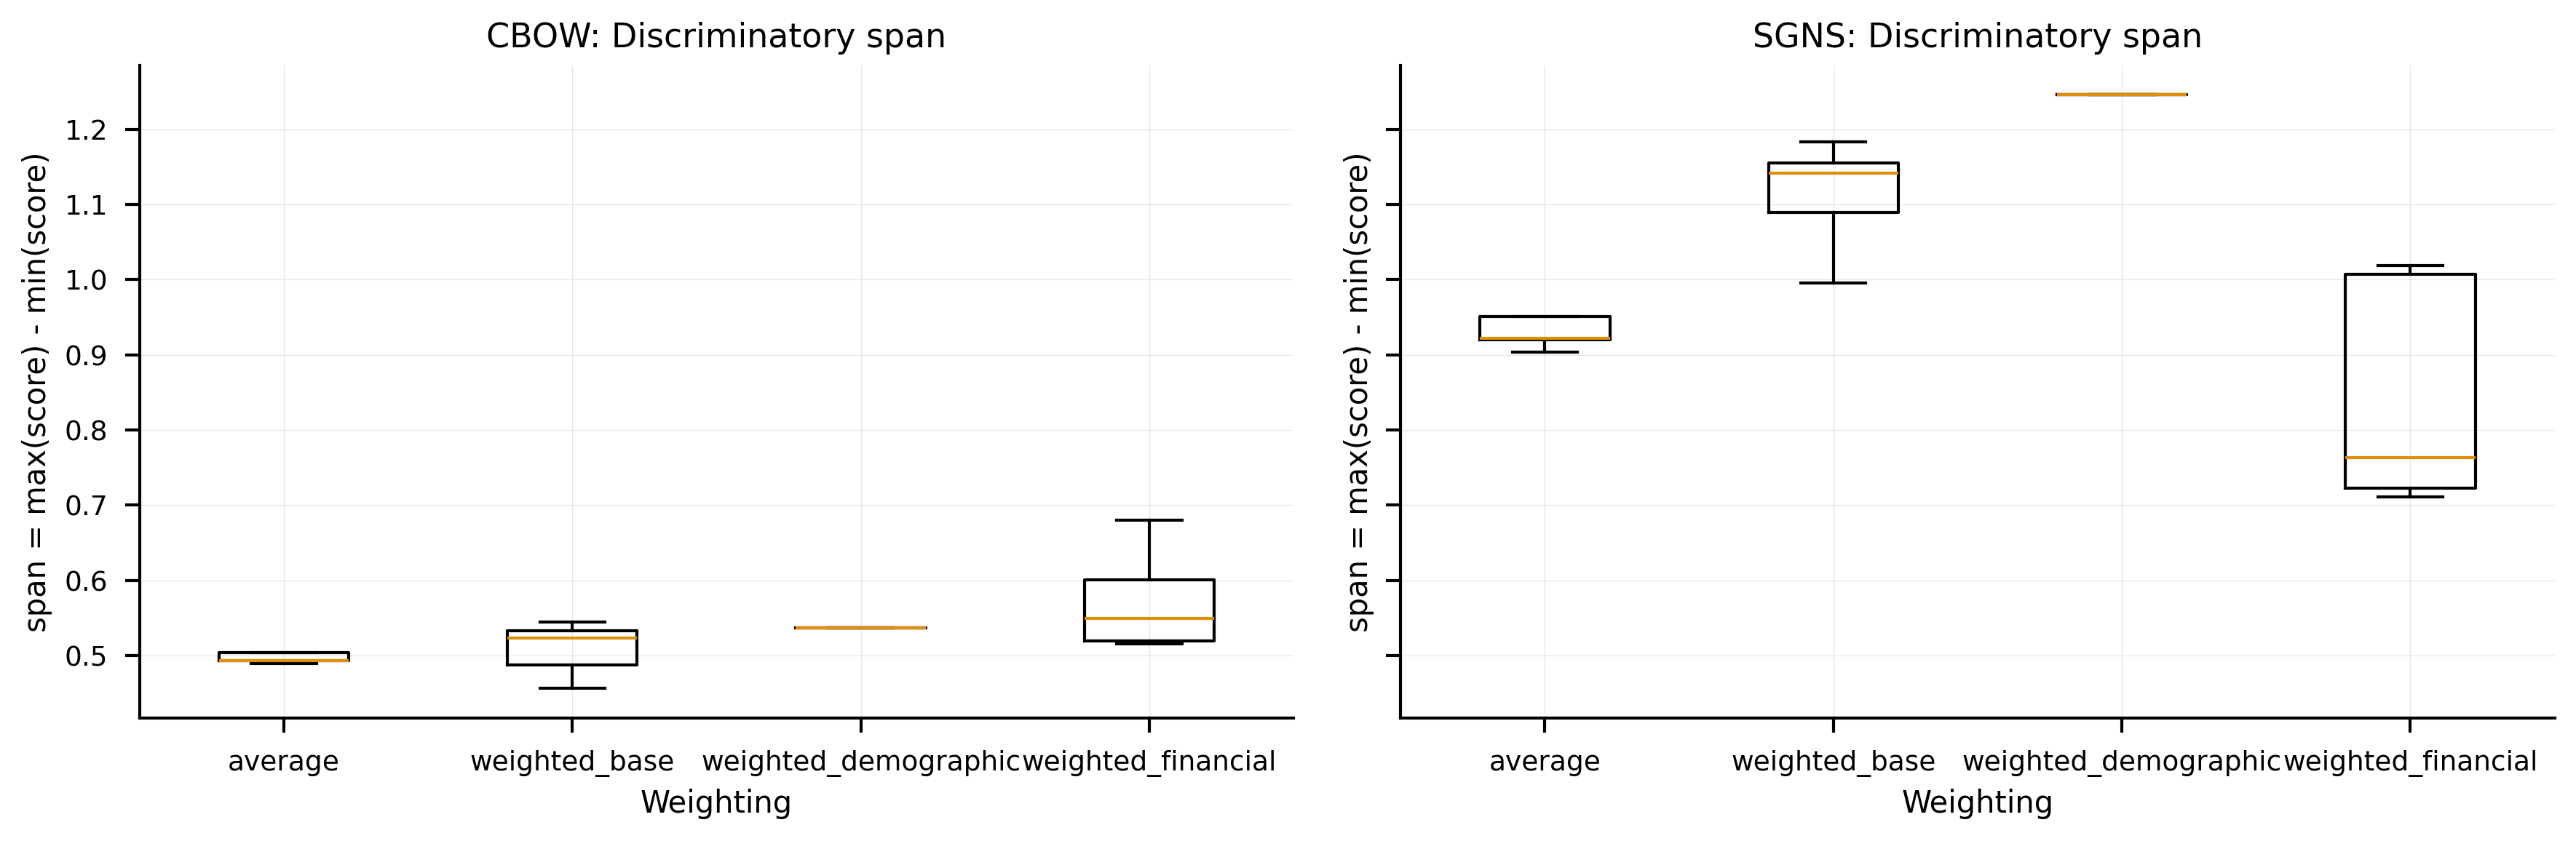

In [11]:
fig = plot_span_box(stats_all)
plt.show()